In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import xlim, ylim

In [3]:
df = pd.read_csv("data/cost_revenue_dirty.csv")

In [4]:
df.shape

(5391, 6)

In [9]:
df.isna().values.any()

np.False_

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

Rank                     int64
Release_Date               str
Movie_Title                str
USD_Production_Budget      str
USD_Worldwide_Gross        str
USD_Domestic_Gross         str
dtype: object

In [19]:
df["USD_Production_Budget"] = df["USD_Production_Budget"].str.replace(r'[$,]','',regex=True).astype(int)

AttributeError: Can only use .str accessor with string values, not integer

In [14]:
df.dtypes

Rank                     int64
Release_Date               str
Movie_Title                str
USD_Production_Budget    int64
USD_Worldwide_Gross        str
USD_Domestic_Gross         str
dtype: object

In [16]:
df["USD_Domestic_Gross"] = df["USD_Domestic_Gross"].str.replace(r'[$,]','',regex=True).astype(int)

In [18]:
df["USD_Worldwide_Gross"] = df["USD_Worldwide_Gross"].str.replace(r'[$,]','',regex=True).astype(int)

In [20]:
df

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,8/2/1915,The Birth of a Nation,110000,11000000,10000000
1,5140,5/9/1916,Intolerance,385907,0,0
2,5230,12/24/1916,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,9/17/1920,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1/1/1925,The Big Parade,245000,22000000,11000000
...,...,...,...,...,...,...
5386,2950,10/8/2018,Meg,15000000,0,0
5387,126,12/18/2018,Aquaman,160000000,0,0
5388,96,12/31/2020,Singularity,175000000,0,0
5389,1119,12/31/2020,Hannibal the Conqueror,50000000,0,0


In [21]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"],format='%m/%d/%Y')

In [22]:
df.dtypes

Rank                              int64
Release_Date             datetime64[us]
Movie_Title                         str
USD_Production_Budget             int64
USD_Worldwide_Gross               int64
USD_Domestic_Gross                int64
dtype: object

In [24]:
# average production budget of the films
average_production_budget = df["USD_Production_Budget"].mean()
average_production_budget

np.float64(31113737.57837136)

In [25]:
df["USD_Production_Budget"].sum()

np.int64(167734159285)

In [26]:
df.mean(numeric_only=True)

Rank                     2.696000e+03
USD_Production_Budget    3.111374e+07
USD_Worldwide_Gross      8.885542e+07
USD_Domestic_Gross       4.123552e+07
dtype: float64

In [27]:
# minimums for worldwide and domestic revenue
worlwide_min = df.USD_Worldwide_Gross.min()
worlwide_min

np.int64(0)

In [28]:
domestic_min = df.USD_Worldwide_Gross.min()
domestic_min

np.int64(0)

In [32]:
df.describe()

,Rank,Release_Date,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
count,5391.000000,5391,5.391000e+03,5.391000e+03,5.391000e+03
mean,2696.000000,2003-09-19 15:02:02.203672,3.111374e+07,8.885542e+07,4.123552e+07
min,1.000000,1915-08-02 00:00:00,1.100000e+03,0.000000e+00,0.000000e+00
25%,1348.500000,1999-12-02 12:00:00,5.000000e+06,3.865206e+06,1.330902e+06
50%,2696.000000,2006-06-23 00:00:00,1.700000e+07,2.745045e+07,1.719220e+07
75%,4043.500000,2011-11-23 00:00:00,4.000000e+07,9.645446e+07,5.234369e+07
max,5391.000000,2020-12-31 00:00:00,4.250000e+08,2.783919e+09,9.366622e+08
std,1556.391981,NaN,4.052380e+07,1.684578e+08,6.602935e+07


In [33]:
df[df.USD_Production_Budget == 1100]

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
2427,5391,2005-05-08,My Date With Drew,1100,181041,181041


In [34]:
df[df.USD_Production_Budget == 4.250000e+08]

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
3529,1,2009-12-18,Avatar,425000000,2783918982,760507625


In [45]:
zero_domestic_gross = df[df.USD_Domestic_Gross==0]
len(zero_domestic_gross)

512

In [46]:
zero_domestic_gross.sort_values("USD_Production_Budget",ascending=False)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5090,556,2015-12-31,"Don Gato, el inicio de la pandilla",80000000,4547660,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


In [47]:
zero_worldwide_gross = df[df.USD_Worldwide_Gross==0]
len(zero_worldwide_gross)

357

In [50]:
zero_worldwide_gross.sort_values("USD_Production_Budget",ascending=False)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5058,880,2015-11-12,The Ridiculous 6,60000000,0,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


In [51]:
international_releases = df.loc[(df.USD_Domestic_Gross == 0) & (df.USD_Worldwide_Gross != 0)]
international_releases.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
71,4310,1956-02-16,Carousel,3380000,3220,0
1579,5087,2001-02-11,Everything Put Together,500000,7890,0
1744,3695,2001-12-31,The Hole,7500000,10834406,0
2155,4236,2003-12-31,Nothing,4000000,63180,0
2203,2513,2004-03-31,The Touch,20000000,5918742,0


In [53]:
international_releases_2 = df.query("USD_Domestic_Gross == 0 and USD_Worldwide_Gross != 0")
international_releases_2.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
71,4310,1956-02-16,Carousel,3380000,3220,0
1579,5087,2001-02-11,Everything Put Together,500000,7890,0
1744,3695,2001-12-31,The Hole,7500000,10834406,0
2155,4236,2003-12-31,Nothing,4000000,63180,0
2203,2513,2004-03-31,The Touch,20000000,5918742,0


In [58]:
# films not released as at the time of data collection
scrape_date = pd.Timestamp('2018-5-1')
future_releases = df[df.Release_Date >= scrape_date]
print(len(future_releases))
future_releases

7


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5386,2950,2018-10-08,Meg,15000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5388,96,2020-12-31,Singularity,175000000,0,0
5389,1119,2020-12-31,Hannibal the Conqueror,50000000,0,0
5390,2517,2020-12-31,"Story of Bonnie and Clyde, The",20000000,0,0


In [59]:
data_clean = df.drop(future_releases.index)

In [60]:
money_losing = data_clean.query("USD_Production_Budget > USD_Worldwide_Gross")
money_losing.shape

(2007, 6)

In [62]:
(money_losing.shape[0]/data_clean.shape[0])*100

37.27711738484398

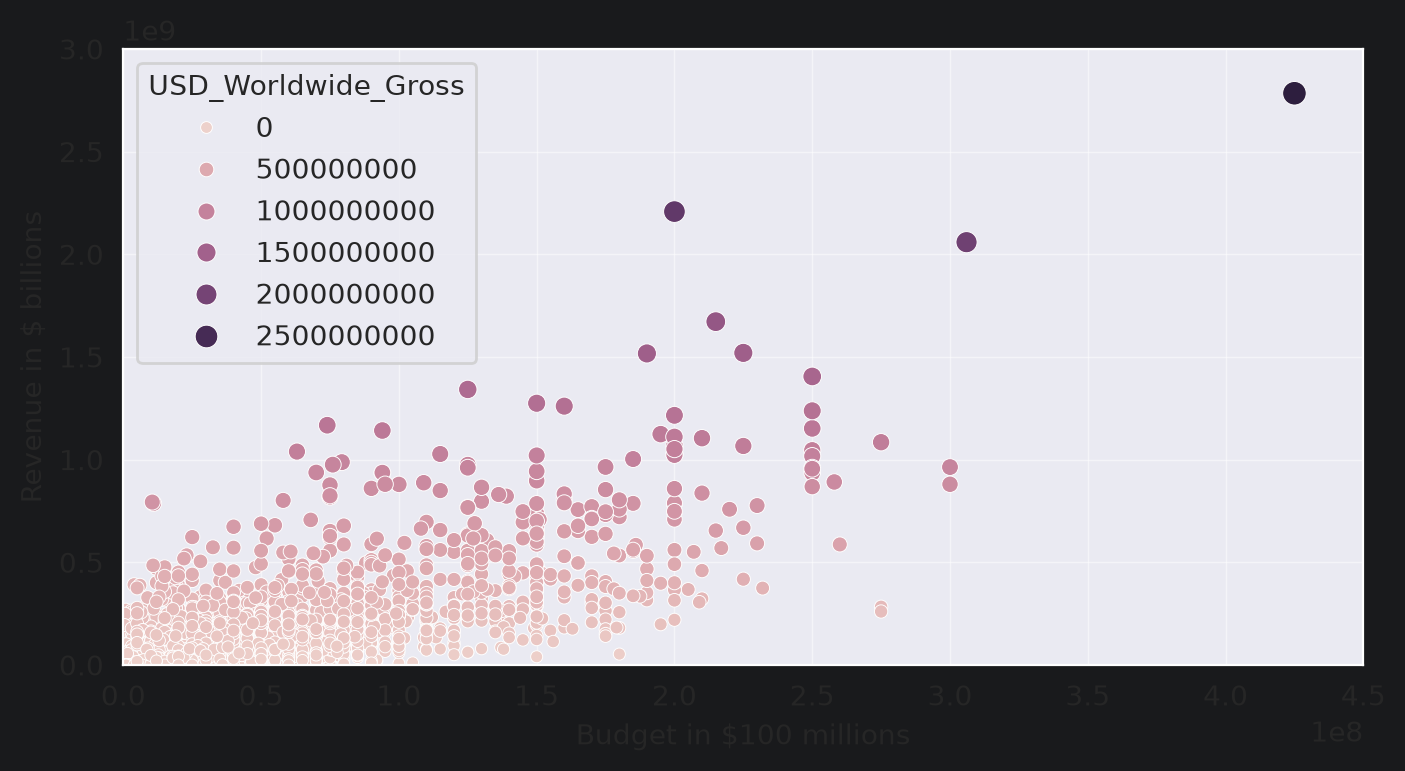

In [69]:
plt.figure(figsize=(8,4),dpi=200)
# set styling on a single chart
with sns.axes_style('darkgrid'):
    ax = sns.scatterplot(data=data_clean,x="USD_Production_Budget",y="USD_Worldwide_Gross",hue='USD_Worldwide_Gross',size='USD_Worldwide_Gross')
    ax.set(ylim=(0, 3000000000),xlim=(0, 450000000),ylabel='Revenue in $ billions',xlabel='Budget in $100 millions')


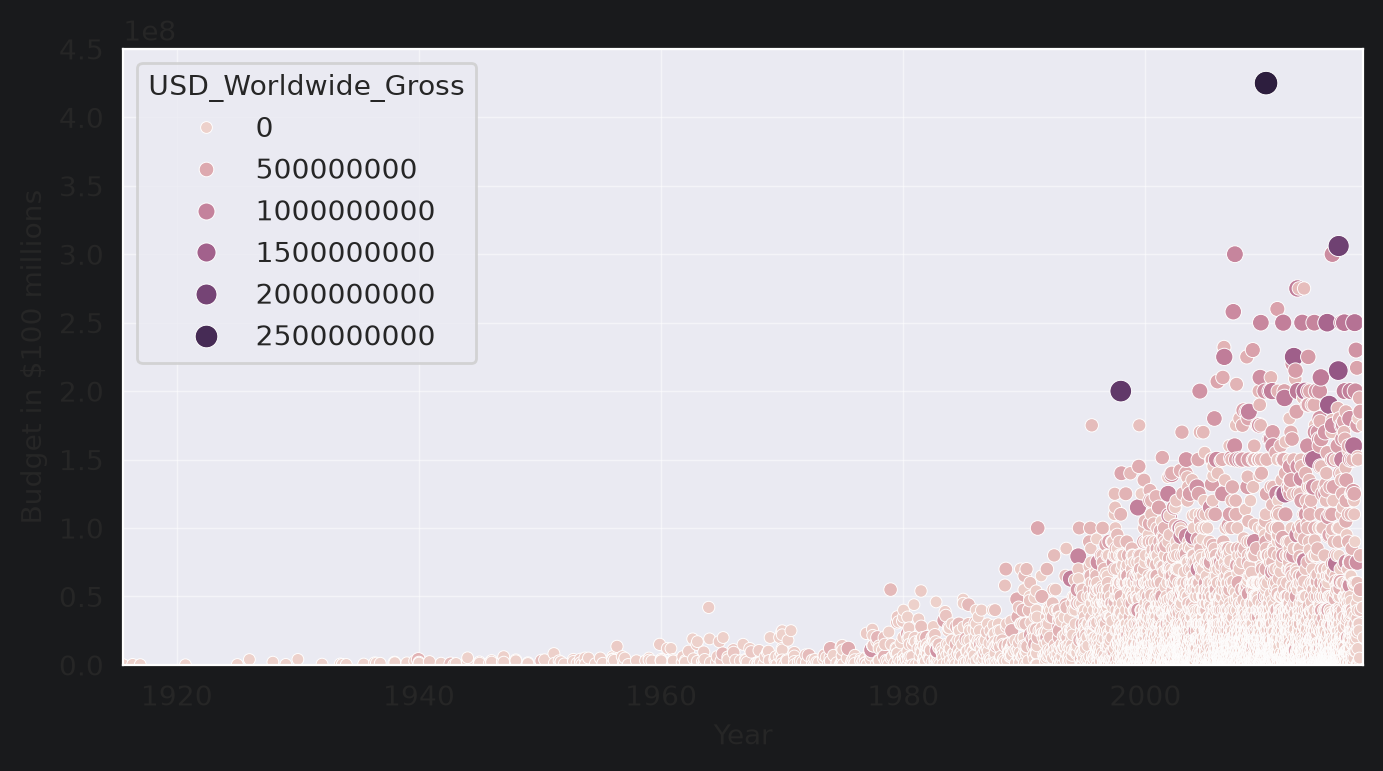

In [73]:
plt.figure(figsize=(8,4),dpi=200)
# set styling on a single chart
with sns.axes_style('darkgrid'):
    ax = sns.scatterplot(data=data_clean,x="Release_Date",y="USD_Production_Budget",hue='USD_Worldwide_Gross',size='USD_Worldwide_Gross')
    ax.set(ylim=(0, 450000000),xlim=(data_clean.Release_Date.min(),data_clean.Release_Date.max()),ylabel='Budget in $100 millions',xlabel='Year')


In [74]:
release_dates = pd.DatetimeIndex(data_clean['Release_Date'])
release_dates

DatetimeIndex(['1915-08-02', '1916-05-09', '1916-12-24', '1920-09-17',
               '1925-01-01', '1925-12-30', '1927-12-08', '1929-01-02',
               '1930-01-01', '1931-12-31',
               ...
               '2017-08-25', '2017-09-06', '2017-09-06', '2017-10-02',
               '2017-10-02', '2017-10-02', '2017-10-03', '2017-12-05',
               '2017-12-05', '2017-12-31'],
              dtype='datetime64[us]', name='Release_Date', length=5384, freq=None)

In [75]:
release_years = release_dates.year
release_years

Index([1915, 1916, 1916, 1920, 1925, 1925, 1927, 1929, 1930, 1931,
       ...
       2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017],
      dtype='int32', name='Release_Date', length=5384)

In [76]:
data_clean['Decade'] = (release_years // 10) * 10

In [91]:
data_clean[['Release_Date', 'Decade']].head()

,Release_Date,Decade
0,1915-08-02,1910
1,1916-05-09,1910
2,1916-12-24,1910
3,1920-09-17,1920
4,1925-01-01,1920


In [92]:
old_films = data_clean[data_clean.Decade <= 1960]
new_films = data_clean[data_clean.Decade > 1960]

In [93]:
old_films.describe()

,Rank,Release_Date,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Decade
count,153.000000,153,1.530000e+02,1.530000e+02,1.530000e+02,153.000000
mean,4274.771242,1954-06-10 04:04:42.352942,4.611298e+06,3.041963e+07,2.238947e+07,1949.150327
min,1253.000000,1915-08-02 00:00:00,1.000000e+05,0.000000e+00,0.000000e+00,1910.000000
25%,3973.000000,1946-01-01 00:00:00,1.250000e+06,5.273000e+06,5.000000e+06,1940.000000
50%,4434.000000,1956-12-23 00:00:00,2.900000e+06,1.000000e+07,1.000000e+07,1950.000000
75%,4785.000000,1964-10-22 00:00:00,5.000000e+06,3.320810e+07,2.835000e+07,1960.000000
max,5299.000000,1969-12-19 00:00:00,4.200000e+07,3.905252e+08,1.986805e+08,1960.000000
std,742.137130,NaN,5.713649e+06,5.493183e+07,3.264175e+07,12.719014


In [94]:
old_films.sort_values("USD_Production_Budget",ascending=False).head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Decade
109,1253,1963-12-06,Cleopatra,42000000,71000000,57000000,1960
150,2175,1969-12-16,"Hello, Dolly",24000000,33208099,33208099,1960
118,2425,1965-02-15,The Greatest Story Ever Told,20000000,15473333,15473333,1960
143,2465,1969-01-01,Sweet Charity,20000000,8000000,8000000,1960
148,2375,1969-10-15,Paint Your Wagon,20000000,31678778,31678778,1960


<Axes: xlabel='USD_Production_Budget', ylabel='USD_Worldwide_Gross'>

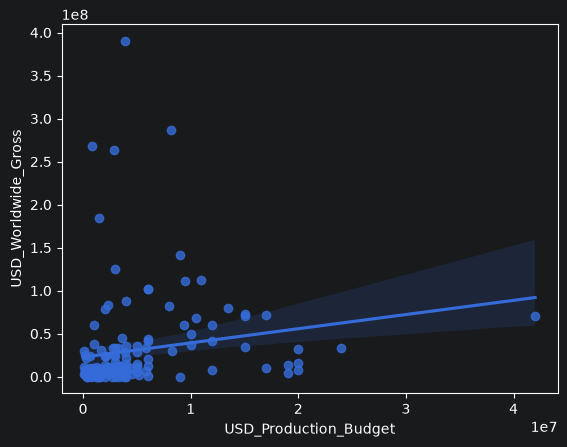

In [95]:
sns.regplot(data=old_films,
            x='USD_Production_Budget',
            y='USD_Worldwide_Gross')

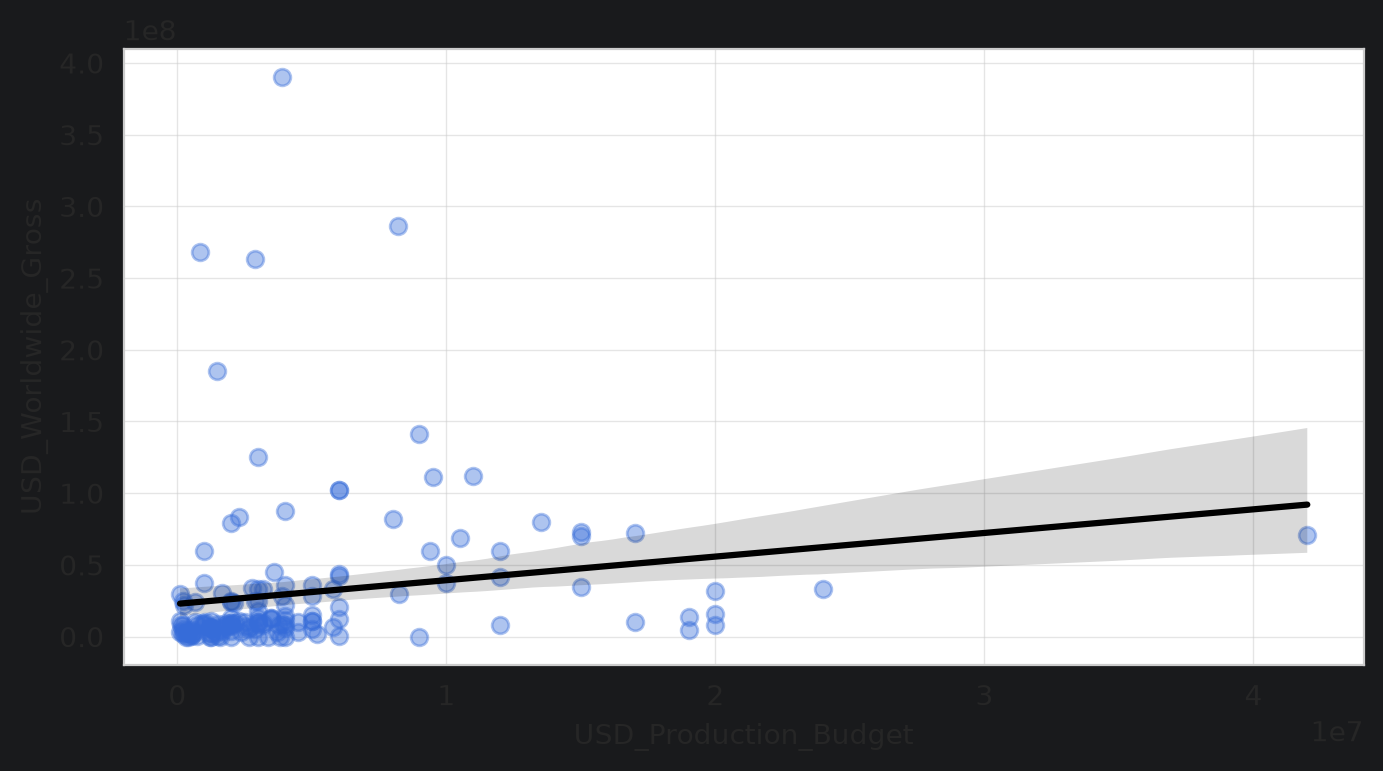

In [96]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style("whitegrid"):
  sns.regplot(data=old_films,
            x='USD_Production_Budget',
            y='USD_Worldwide_Gross',
            scatter_kws = {'alpha': 0.4},
            line_kws = {'color': 'black'})

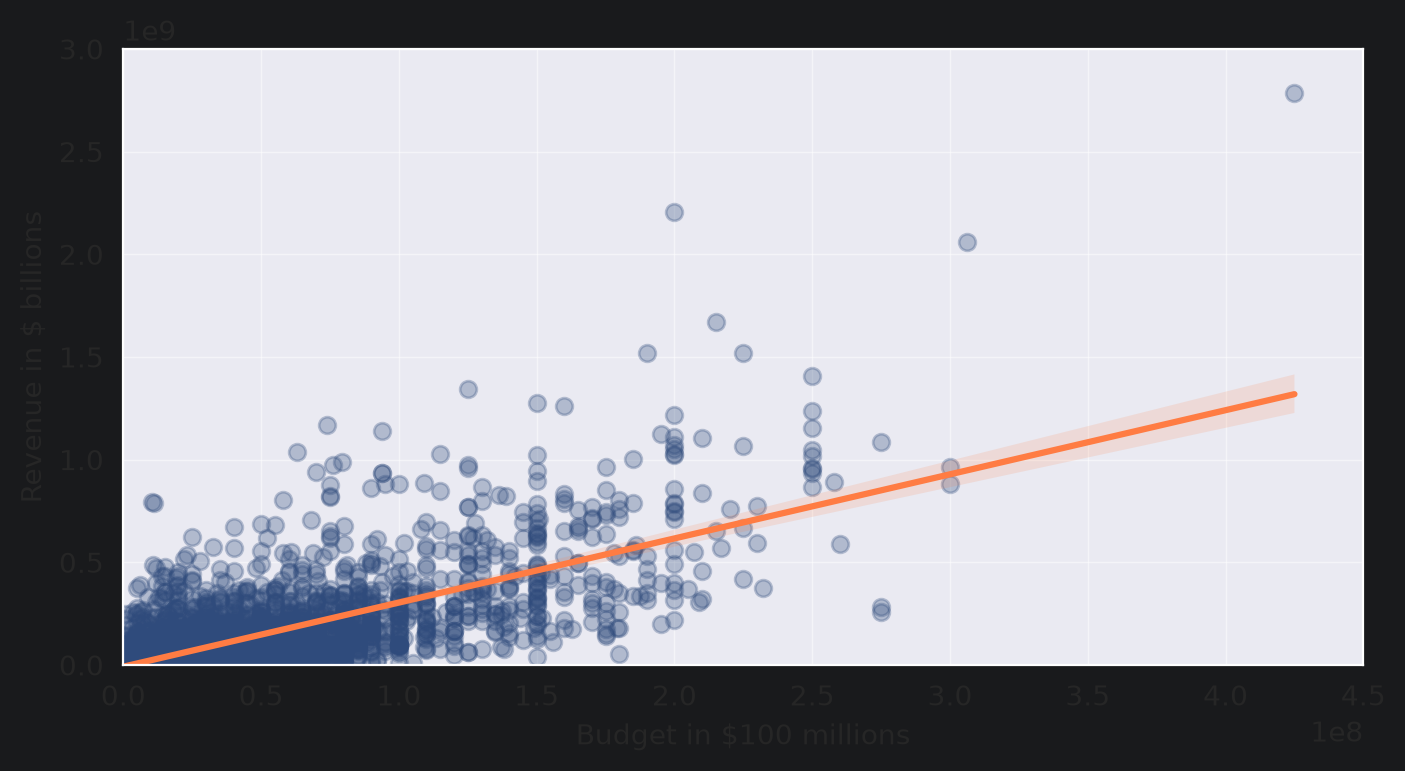

In [97]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('darkgrid'):
  ax = sns.regplot(data=new_films,
                   x='USD_Production_Budget',
                   y='USD_Worldwide_Gross',
                   color='#2f4b7c',
                   scatter_kws = {'alpha': 0.3},
                   line_kws = {'color': '#ff7c43'})

  ax.set(ylim=(0, 3000000000),
         xlim=(0, 450000000),
         ylabel='Revenue in $ billions',
         xlabel='Budget in $100 millions')